# Comparação final — todos os modelos

Lê `results/model_comparison.csv` (preenchido pela DNN e pelos baselines). Rode os outros notebooks primeiro.

In [1]:
import os, sys
# garante o cwd na raiz do repo (onde ficam data/ e support_scripts/)
while not os.path.isdir('support_scripts') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.append('support_scripts')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import data_prep as dp, sk_eval

d = dp.get_data()
print(f"{len(d['df'])} animais | {len(d['scale_cols'])} preditores | "
      f"{d['groups'].value_counts().to_dict()}")

245 animais | 9 preditores | {'elvis': 113, 'humberto': 71, 'sonico': 61}


## Tabela + gráfico

baseline MAE (média): 0.0793


,model,cv_MAE,cv_MAE_std,cv_R2,cv_R2_std,lopo_MAE,lopo_R2
0,MLP_DNN,0.0274,0.0062,0.8381,0.1081,0.3090,-51.5039
1,GradientBoosting,0.0524,0.0093,0.5034,0.3104,0.0936,-0.9624
2,RandomForest,0.0554,0.0111,0.4802,0.3441,0.0778,0.0294
3,Linear,0.0647,0.0073,0.4239,0.2451,0.3671,-66.3023


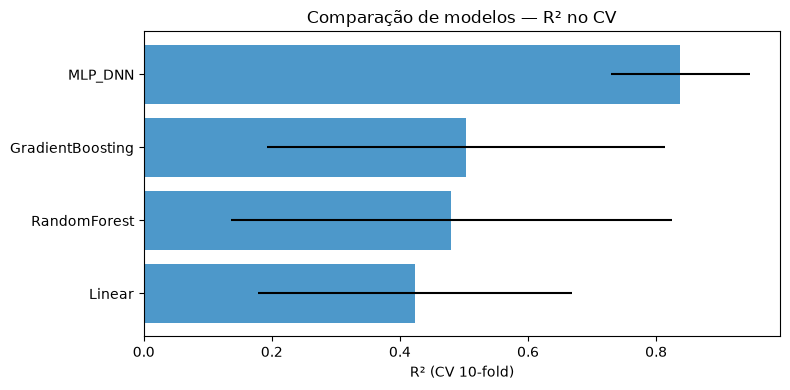

In [2]:
comp = pd.read_csv(dp.RESULTS_PATH).sort_values('cv_R2', ascending=False).reset_index(drop=True)
base = dp.baseline_mae(d['df'][dp.TARGET], d['df'][dp.TARGET])
print(f'baseline MAE (média): {base:.4f}')
display(comp.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(comp.model, comp.cv_R2, xerr=comp.cv_R2_std, color='#2e86c1', alpha=.85)
ax.set_xlabel('R² (CV 10-fold)'); ax.set_title('Comparação de modelos — R² no CV')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

- `cv_*` = CV 10-fold (métrica principal) · `lopo_*` = média do leave-one-property-out.
- Próximo: **SHAP** sobre o melhor modelo.